In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv(r'C:\Projects_ciência_dados\students_performance\data\raw\StudentsPerformance.csv')

In [3]:
dataset.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
dataset.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [13]:
media = (dataset["math score"].mean() + dataset["reading score"].mean() + dataset["writing score"].mean())/3

In [16]:
media

np.float64(67.77066666666666)

In [ ]:
dataset["Desempenho"] = np.where((dataset["math score"] + dataset["reading score"] + dataset["writing score"])/3 >= media,1,0)

In [18]:
dataset

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Desempenho
0,female,group B,bachelor's degree,standard,none,72,72,74,1
1,female,group C,some college,standard,completed,69,90,88,1
2,female,group B,master's degree,standard,none,90,95,93,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,0
4,male,group C,some college,standard,none,76,78,75,1
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,1
996,male,group C,high school,free/reduced,none,62,55,55,0
997,female,group C,high school,free/reduced,completed,59,71,65,0
998,female,group D,some college,standard,completed,68,78,77,1


In [19]:
np.unique(dataset["Desempenho"], return_counts=True)

(array([0, 1]), array([474, 526]))

##### Filhos de pais que só possuem ensino médio se sairam mais mal do que bem

<Axes: xlabel='parental level of education', ylabel='count'>

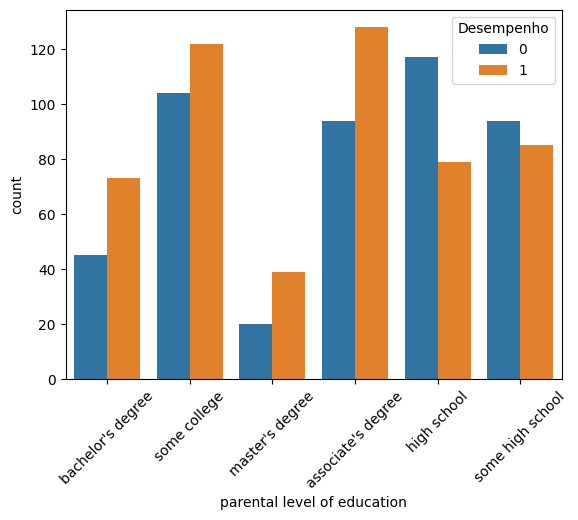

In [25]:
plt.xticks(rotation=45)
sns.countplot(data=dataset, x="parental level of education", hue="Desempenho")

##### Filhos de pais que possuem mestrado se sairam melhor

<Axes: xlabel='parental level of education', ylabel='Desempenho'>

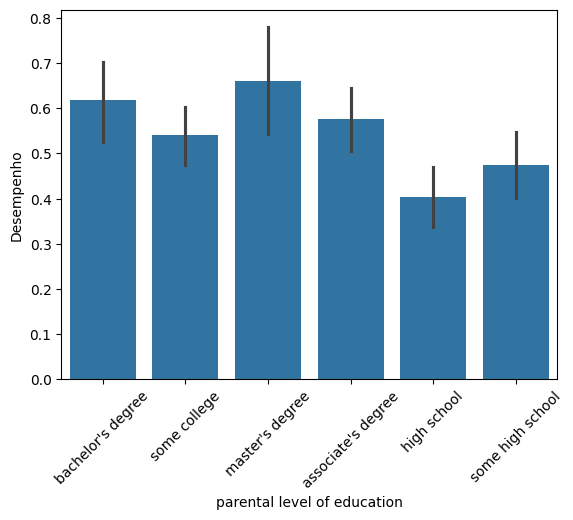

In [28]:
plt.xticks(rotation=45)
sns.barplot(data=dataset, x="parental level of education", y="Desempenho")

#### Mulheres apresentam melhor desempenho que homens

<Axes: xlabel='gender', ylabel='Desempenho'>

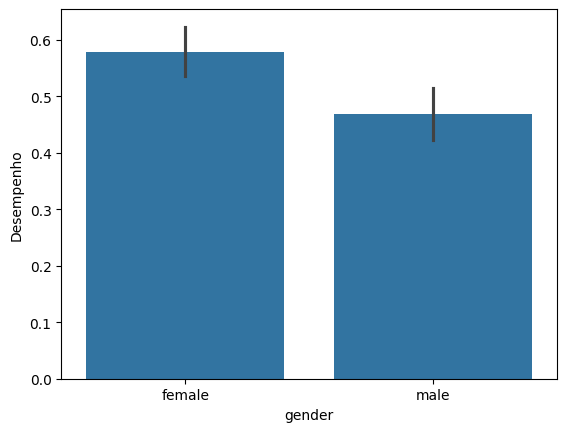

In [29]:
sns.barplot(data=dataset, x="gender", y="Desempenho")

<Axes: xlabel='gender', ylabel='count'>

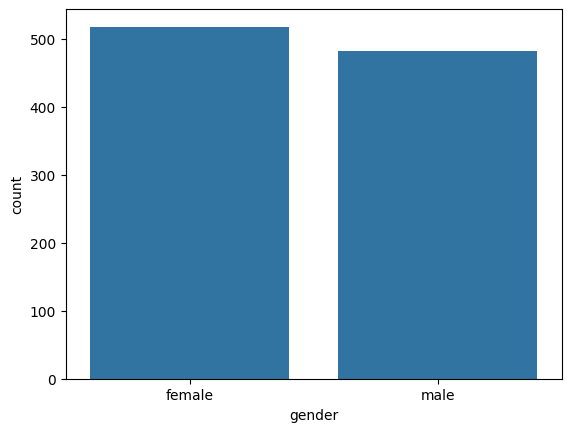

In [30]:
sns.countplot(data=dataset, x="gender")

In [33]:
mulheres_desempenho = dataset.loc[(dataset["gender"] == "female") & (dataset["Desempenho"] == 1)].shape[0]

In [34]:
mulheres_desempenho

300

In [36]:
dataset.loc[dataset["gender"] == "female"].shape[0]

518

###### 57,9% das mulheres tiveram desempenho acima da média

In [ ]:
(mulheres_desempenho/518)*100 

57.91505791505791

In [39]:
homens_desempenho = dataset.loc[(dataset["gender"] == "male") & (dataset["Desempenho"] == 1)].shape[0]
homens_desempenho

226

In [40]:
dataset.loc[dataset["gender"] == "male"].shape[0]

482

###### 46,8% dos homens tiveram desempenho acima da média

In [41]:
(homens_desempenho/482)*100

46.88796680497925

In [42]:
dataset

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Desempenho
0,female,group B,bachelor's degree,standard,none,72,72,74,1
1,female,group C,some college,standard,completed,69,90,88,1
2,female,group B,master's degree,standard,none,90,95,93,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,0
4,male,group C,some college,standard,none,76,78,75,1
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,1
996,male,group C,high school,free/reduced,none,62,55,55,0
997,female,group C,high school,free/reduced,completed,59,71,65,0
998,female,group D,some college,standard,completed,68,78,77,1


In [49]:
genero_materia = pd.DataFrame({
    "genero":dataset["gender"],
    "matematica":dataset["math score"],
    "leitura":dataset["writing score"],
    "escrita":dataset["writing score"]
})

In [51]:
genero_materia.describe()

,matematica,leitura,escrita
count,1000.00000,1000.000000,1000.000000
mean,66.08900,68.054000,68.054000
std,15.16308,15.195657,15.195657
min,0.00000,10.000000,10.000000
25%,57.00000,57.750000,57.750000
50%,66.00000,69.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [54]:
genero_materia.loc[(genero_materia["genero"] == "female") & (genero_materia["matematica"] > 66.08)].shape[0]

221

##### Porcentagem de mulheres que tiveram resultado acima da média em matemática

In [55]:
(221/518)*100

42.664092664092664

In [56]:
genero_materia.loc[(genero_materia["genero"] == "male") & (genero_materia["matematica"] > 66.08)].shape[0]

272

##### Porcentagem de homens que apresentaram resultado acima da média em matemática

In [57]:
(272/482)*100

56.43153526970954

In [62]:
genero_materia.loc[(genero_materia["genero"] == "female") & (genero_materia["leitura"] > 68.05)].shape[0]

333

##### Porcentagem de mulheres que apresentam desempenho acima da média em leitura

In [63]:
(333/518)*100

64.28571428571429

In [64]:
genero_materia.loc[(genero_materia["genero"] == "male") & (genero_materia["leitura"] > 68.05)].shape[0]

179

##### Porcentagem de homens que apresentam desempenho acima da média em leitura

In [65]:
(179/482)*100

37.136929460580916

In [66]:
genero_materia.loc[(genero_materia["genero"] == "female") & (genero_materia["escrita"] > 68.05)].shape[0]

333

##### Porcentagem de mulheres que possuem desempenho acima da média em escrita

In [67]:
(333/518)*100

64.28571428571429

In [68]:
genero_materia.loc[(genero_materia["genero"] == "male") & (genero_materia["escrita"] > 68.05)].shape[0]

179

##### Porcentagem de homens que possuem resultados acima da média em escrita

In [69]:
(179/482)*100

37.136929460580916

In [ ]:
disciplinas_plot = ['Matemática', 'Leitura', 'Escrita']
mulheres_plot = [42.7, 64.28, 64.28]  
homens_plot = [56.4, 37.13, 37.13]    

In [71]:
x = range(len(disciplinas_plot))
width = 0.35

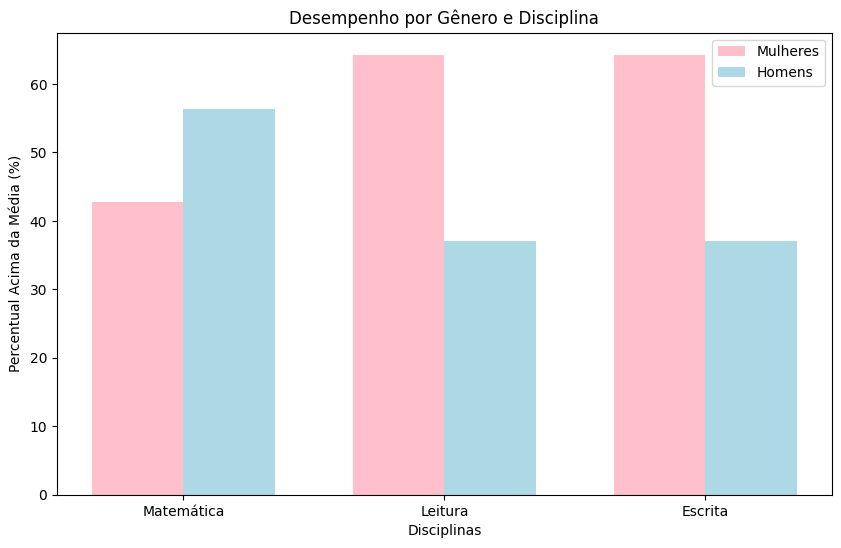

In [73]:
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - width/2 for i in x], mulheres_plot, width, label='Mulheres', color='pink')
bars2 = ax.bar([i + width/2 for i in x], homens_plot, width, label='Homens', color='lightblue')

ax.set_xlabel('Disciplinas')
ax.set_ylabel('Percentual Acima da Média (%)')
ax.set_title('Desempenho por Gênero e Disciplina')
ax.set_xticks(x)
ax.set_xticklabels(disciplinas_plot)
ax.legend()

plt.show()

In [74]:
dataset.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'Desempenho'],
      dtype='object')

In [76]:
np.unique(dataset["race/ethnicity"], return_counts=True)

(array(['group A', 'group B', 'group C', 'group D', 'group E'],
       dtype=object),
 array([ 89, 190, 319, 262, 140]))

##### Etnia E apresentou melhor desempenho

<Axes: xlabel='race/ethnicity', ylabel='Desempenho'>

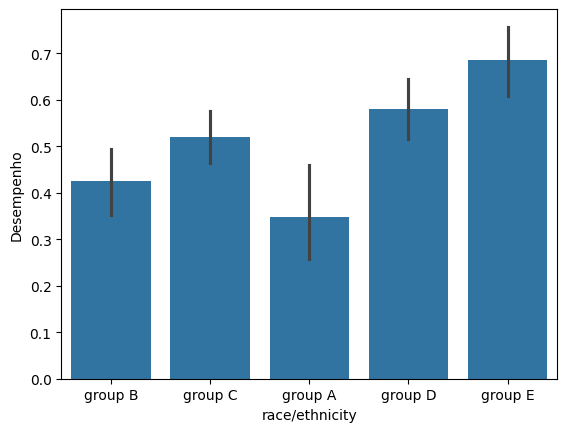

In [77]:
sns.barplot(data=dataset, x="race/ethnicity", y="Desempenho")

##### Pessoas que almoçam grátis possuem um pior desempenho

<Axes: xlabel='lunch', ylabel='Desempenho'>

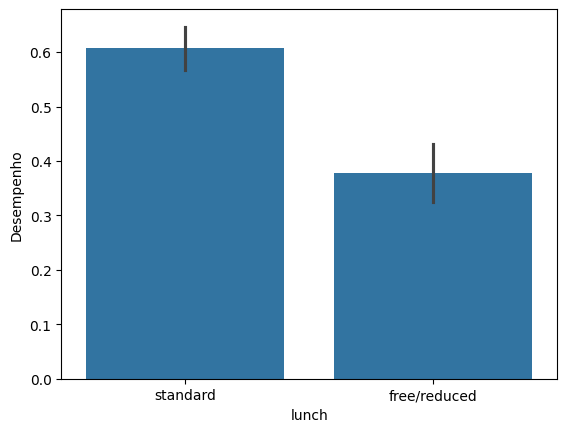

In [79]:
sns.barplot(data=dataset, x="lunch", y="Desempenho")

##### Escrita e leitura possuem forte correlação

Text(0.5, 1.0, 'Correlação entre Disciplinas')

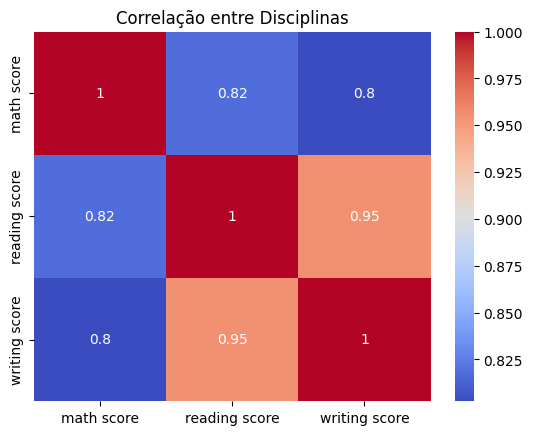

In [80]:
correlation_matrix = dataset[['math score', 'reading score', 'writing score']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlação entre Disciplinas')

##### Educação dos pais não possui forte relação com fatores econômicos

📊 TABELA DE PERCENTUAIS:
lunch                        free/reduced  standard
parental level of education                        
associate's degree                  34.68     65.32
bachelor's degree                   37.29     62.71
high school                         35.71     64.29
master's degree                     40.68     59.32
some college                        34.96     65.04
some high school                    34.08     65.92


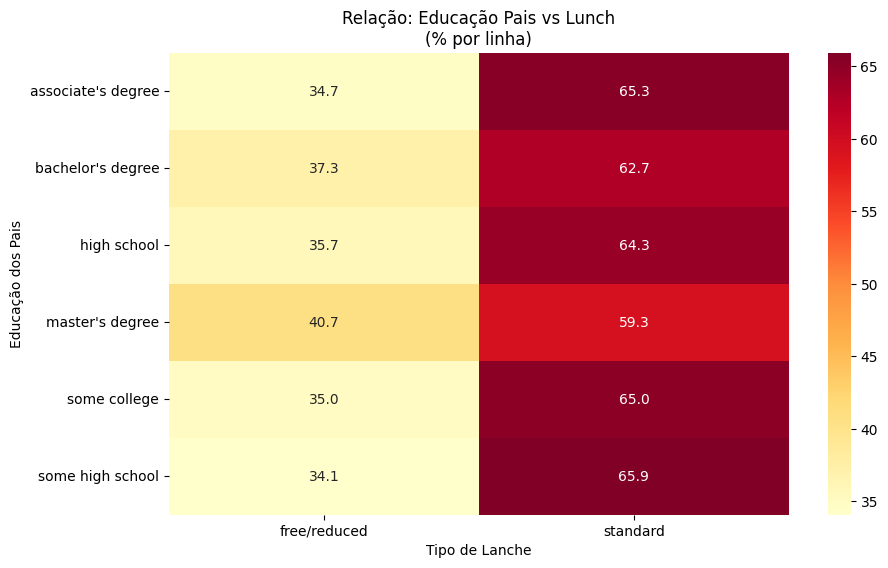

In [82]:
# Primeiro, criar a tabela_percentual
tabela_percentual = pd.crosstab(dataset['parental level of education'], 
                               dataset['lunch'],
                               normalize='index') * 100

print("📊 TABELA DE PERCENTUAIS:")
print(tabela_percentual.round(2))

# AGORA plotar o heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(tabela_percentual, annot=True, cmap='YlOrRd', fmt='.1f')
plt.title('Relação: Educação Pais vs Lunch\n(% por linha)')
plt.ylabel('Educação dos Pais')
plt.xlabel('Tipo de Lanche')
plt.show()

In [83]:
dataset.to_csv('../data/interim/dataset_interim.csv', index=False)

In [84]:
type(dataset)

pandas.core.frame.DataFrame